In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import random
import numpy as np
from typing import Dict, Tuple, List

# 環境設定 (仮の値を設定。実際の環境に合わせてください)
GRID_SIZE = 10
NUM_AGENTS = 2
NUM_ORDERS = 3
DROPOFF_LOCATION = (5, 5) # 以前のコードで定義された変数を参照

# --- 1-1. MLPAgent (RNNの代わり) ---
class MLPAgent(nn.Module):
    """RNNを使用しない、よりシンプルなエージェントネットワーク"""
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(MLPAgent, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )
    def forward(self, x):
        # 隠れ状態 h は不要なため、Q値のみを返す
        return self.net(x)

# --- 1-2. QMixer (ハイパーネットワークはそのまま使用) ---
# QMixerの定義は前回のDeepQMixerのバージョンを流用することを想定。
# (ここではコードは省略しますが、必ず実装してください)
# from DeepQMixer import DeepQMixer as QMixer

In [2]:
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from typing import Dict, Tuple, List
import time
import numpy as np
from IPython import display # Jupyter環境用（オプション）

# 環境設定
GRID_SIZE = 10
NUM_AGENTS = 2
NUM_ORDERS = 3
PICKUP_LOCATIONS = [(1, 1), (8, 1), (5, 8)]
DROPOFF_LOCATION = (5, 5)

class WarehouseEnv:
    def __init__(self, size: int = GRID_SIZE, num_agents: int = NUM_AGENTS):
        self.size = size
        self.num_agents = num_agents
        self.action_space = 5  # 0:待機, 1:上, 2:下, 3:左, 4:右

        # Matplotlib用の図の保持
        self.fig = None
        self.ax = None

        # 状態の初期化
        self.reset()

    def reset(self) -> Dict[int, Tuple]:
        """環境を初期化し、初期状態を返します。"""
        self.agent_positions: Dict[int, Tuple[int, int]] = {
            i: (random.randint(0, self.size - 1), random.randint(0, self.size - 1))
            for i in range(self.num_agents)
        }
        self.agent_holding: Dict[int, bool] = {i: False for i in range(self.num_agents)}
        self.remaining_orders: List[int] = list(range(NUM_ORDERS))
        return self._get_obs()

    def _get_obs(self) -> Dict[int, Tuple]:
        obs = {}
        for i in range(self.num_agents):
            obs[i] = (
                self.agent_positions[i],
                self.agent_holding[i],
                tuple(self.remaining_orders)
            )
        return obs

    def step(self, actions: Dict[int, int]) -> Tuple[Dict, Dict, Dict, Dict]:
        next_positions: Dict[int, Tuple[int, int]] = {}
        rewards: Dict[int, float] = {i: -0.1 for i in range(self.num_agents)}

        # 1. 位置の更新
        for i, action in actions.items():
            current_x, current_y = self.agent_positions[i]
            next_x, next_y = current_x, current_y

            if action == 1: next_y += 1  # 上
            elif action == 2: next_y -= 1  # 下
            elif action == 3: next_x -= 1  # 左
            elif action == 4: next_x += 1  # 右

            next_x = np.clip(next_x, 0, self.size - 1)
            next_y = np.clip(next_y, 0, self.size - 1)
            next_positions[i] = (next_x, next_y)

        # 2. 衝突判定
        final_positions = self.agent_positions.copy()
        is_collision = False

        for i in range(self.num_agents):
            pos = next_positions[i]
            is_colliding = False
            for j in range(self.num_agents):
                if i != j and pos == next_positions[j]:
                    is_colliding = True
                    break
            if is_colliding:
                rewards[i] -= 5.0
                is_collision = True
            else:
                final_positions[i] = pos

        self.agent_positions = final_positions

        # 3. ピックアップ・ドロップオフ
        for i in range(self.num_agents):
            current_pos = self.agent_positions[i]
            if not self.agent_holding[i]:
                for order_idx in self.remaining_orders:
                    if current_pos == PICKUP_LOCATIONS[order_idx]:
                        self.agent_holding[i] = True
                        self.remaining_orders.remove(order_idx)
                        rewards[i] += 10.0
                        break
            elif self.agent_holding[i]:
                if current_pos == DROPOFF_LOCATION:
                    self.agent_holding[i] = False
                    rewards[i] += 50.0

        done = {i: len(self.remaining_orders) == 0 for i in range(self.num_agents)}
        return self._get_obs(), rewards, done, {"collision": is_collision}

    # --- 追加された可視化メソッド ---
    def render(self, mode='text', sleep_time=0.5):
        """
        環境を可視化します。
        mode='text': コンソールに文字で表示
        mode='graphic': Matplotlibで図として表示
        """
        if mode == 'text':
            self._render_text()
        elif mode == 'graphic':
            self._render_graphic(sleep_time)

    def _render_text(self):
        grid = [['.' for _ in range(self.size)] for _ in range(self.size)]

        # 場所のマーク (y座標は下から上へ増えるため、表示時は反転させるか注意が必要)
        # ここでは (0,0) を左下として扱います
        x, y = DROPOFF_LOCATION
        grid[self.size - 1 - y][x] = 'D'  # Dropoff

        for idx in self.remaining_orders:
            x, y = PICKUP_LOCATIONS[idx]
            grid[self.size - 1 - y][x] = 'P'  # Pickup

        for i, pos in self.agent_positions.items():
            x, y = pos
            char = f'A{i}'
            if self.agent_holding[i]:
                char = f'H{i}' # Holding

            # 同じ場所に重なった場合の表示処理（簡易）
            if grid[self.size - 1 - y][x] not in ['.', 'P', 'D']:
                grid[self.size - 1 - y][x] += char
            else:
                grid[self.size - 1 - y][x] = char

        print("-" * (self.size * 3))
        for row in grid:
            print(" ".join([f"{c:>2}" for c in row]))
        print("-" * (self.size * 3))

    # --- WarehouseEnv クラス内の _render_graphic メソッドの修正 ---
    # ⚠️ 注意: これは WarehouseEnv クラスの内部にあると仮定
    def _render_graphic(self, sleep_time):
        # sleep_time はここでは完全に無視される（run_learned_agent側で処理）

        if self.fig is None:
            plt.ioff() # インタラクティブモードをオフにする（描画更新はdisplayに任せる）
            self.fig, self.ax = plt.subplots(figsize=(6, 6))

        self.ax.clear()
        self.ax.set_xlim(-0.5, self.size - 0.5)
        self.ax.set_ylim(-0.5, self.size - 0.5)
        self.ax.set_xticks(range(self.size))
        self.ax.set_yticks(range(self.size))
        self.ax.grid(True)
        self.ax.set_title(f"Orders Remaining: {len(self.remaining_orders)}")

        # ドロップオフ地点 (赤色)
        dx, dy = DROPOFF_LOCATION
        self.ax.add_patch(patches.Rectangle((dx-0.5, dy-0.5), 1, 1, color='red', alpha=0.3, label='Dropoff'))
        self.ax.text(dx, dy, 'Drop', ha='center', va='center', fontsize=8, color='darkred')

        # ピックアップ地点 (青色)
        for idx in self.remaining_orders:
            px, py = PICKUP_LOCATIONS[idx]
            self.ax.add_patch(patches.Rectangle((px-0.5, py-0.5), 1, 1, color='blue', alpha=0.3, label='Pickup'))
            self.ax.text(px, py, 'Pick', ha='center', va='center', fontsize=8, color='darkblue')

        # エージェント (円)
        colors = ['green', 'orange', 'purple', 'cyan']
        for i, pos in self.agent_positions.items():
            ax, ay = pos
            color = colors[i % len(colors)]
            edgecolor = 'black'
            linewidth = 1
            if self.agent_holding[i]:
                linewidth = 3
                edgecolor = 'red' # 荷物持ち強調

            circle = patches.Circle((ax, ay), 0.3, facecolor=color, edgecolor=edgecolor, linewidth=linewidth, label=f'Agent {i}')
            self.ax.add_patch(circle)
            self.ax.text(ax, ay, f'A{i}', ha='center', va='center', color='white', fontweight='bold')

        # 🚨 描画更新と待機を削除！ (run_learned_agent側で処理する)
        # plt.draw()
        # if sleep_time > 0.0:
        #   plt.pause(sleep_time)

    def render_frame(self):
        fig, ax = plt.subplots(figsize=(6, 6))

        ax.set_xlim(-0.5, self.size - 0.5)
        ax.set_ylim(-0.5, self.size - 0.5)
        ax.set_xticks(range(self.size))
        ax.set_yticks(range(self.size))
        ax.grid(True)

        # Dropoff
        dx, dy = DROPOFF_LOCATION
        ax.add_patch(patches.Rectangle((dx-0.5, dy-0.5), 1, 1, color='red', alpha=0.3))

        # Pickup
        for idx in self.remaining_orders:
            px, py = PICKUP_LOCATIONS[idx]
            ax.add_patch(patches.Rectangle((px-0.5, py-0.5), 1, 1, color='blue', alpha=0.3))

        # Agents
        colors = ['green', 'orange', 'purple', 'cyan']
        for i, (x, y) in self.agent_positions.items():
            circle = patches.Circle((x, y), 0.3, color=colors[i % len(colors)])
            ax.add_patch(circle)
            ax.text(x, y, f'A{i}', ha='center', va='center', color='white')

        fig.canvas.draw()
        image = np.asarray(fig.canvas.buffer_rgba())[..., :3]

        plt.close(fig)
        return image


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions import Categorical
import collections

# --- ハイパーパラメータ ---
LR_ACTOR = 3e-4
LR_CRITIC = 3e-4
GAMMA = 0.99
TAU = 0.005
ALPHA = 0.2  # エントロピー正則化係数
BUFFER_LIMIT = 50000
BATCH_SIZE = 64

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 観測の変換関数 ---
def flatten_obs(obs_dict, env_size=GRID_SIZE):
    """(pos, holding, orders) -> flat vector"""
    flats = {}
    for i, (pos, holding, orders) in obs_dict.items():
        # 正規化された位置
        pos_norm = [pos[0] / env_size, pos[1] / env_size]
        # 荷物持ちフラグ
        h_flag = [1.0 if holding else 0.0]
        # 残りオーダー（固定長フラグ化）
        order_flags = [0.0] * NUM_ORDERS
        for o in orders:
            order_flags[o] = 1.0

        flats[i] = torch.FloatTensor(pos_norm + h_flag + order_flags).to(device)
    return flats

# --- モデル定義 ---
class Actor(nn.Module):
    def __init__(self, n_obs, n_actions):
        super(Actor, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(n_obs, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, n_actions)
        )

    def forward(self, x):
        logits = self.fc(x)
        probs = F.softmax(logits, dim=-1)
        return probs

class Critic(nn.Module):
    def __init__(self, n_obs, n_actions):
        super(Critic, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(n_obs, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, n_actions) # 各アクションのQ値を出力
        )

    def forward(self, x):
        return self.fc(x)

# --- SAC エージェント ---
class SACAgent:
    def __init__(self, n_obs, n_actions):
        self.actor = Actor(n_obs, n_actions).to(device)
        self.critic_1 = Critic(n_obs, n_actions).to(device)
        self.critic_2 = Critic(n_obs, n_actions).to(device)
        self.target_critic_1 = Critic(n_obs, n_actions).to(device)
        self.target_critic_2 = Critic(n_obs, n_actions).to(device)
        self.target_critic_1.load_state_dict(self.critic_1.state_dict())
        self.target_critic_2.load_state_dict(self.critic_2.state_dict())

        self.actor_optimizer = optim.Adam(self.actor.parameters(), lr=LR_ACTOR)
        self.critic_optimizer = optim.Adam(list(self.critic_1.parameters()) + list(self.critic_2.parameters()), lr=LR_CRITIC)
        self.n_actions = n_actions

    def get_action(self, obs):
        probs = self.actor(obs)
        dist = Categorical(probs)
        return dist.sample().item()

    def train(self, transitions):
        s, a, r, s_prime, done = zip(*transitions)
        s = torch.stack(s); a = torch.tensor(a).unsqueeze(1).to(device)
        r = torch.tensor(r).unsqueeze(1).to(device); s_prime = torch.stack(s_prime)
        done = torch.tensor(done).unsqueeze(1).to(device)

        # Critic Update
        with torch.no_grad():
            next_probs = self.actor(s_prime)
            next_log_probs = torch.log(next_probs + 1e-8)
            target_q1 = self.target_critic_1(s_prime)
            target_q2 = self.target_critic_2(s_prime)
            target_v = torch.sum(next_probs * (torch.min(target_q1, target_q2) - ALPHA * next_log_probs), dim=1, keepdim=True)
            target_q = r + GAMMA * (1 - done.float()) * target_v

        q1 = self.critic_1(s).gather(1, a)
        q2 = self.critic_2(s).gather(1, a)
        critic_loss = F.mse_loss(q1, target_q) + F.mse_loss(q2, target_q)

        self.critic_optimizer.zero_grad()
        critic_loss.backward()
        self.critic_optimizer.step()

        # Actor Update
        probs = self.actor(s)
        log_probs = torch.log(probs + 1e-8)
        q1 = self.critic_1(s)
        q2 = self.critic_2(s)
        min_q = torch.min(q1, q2)

        actor_loss = torch.sum(probs * (ALPHA * log_probs - min_q), dim=1).mean()

        self.actor_optimizer.zero_grad()
        actor_loss.backward()
        self.actor_optimizer.step()

        # Soft Target Update
        for target_param, param in zip(self.target_critic_1.parameters(), self.critic_1.parameters()):
            target_param.data.copy_(target_param.data * (1.0 - TAU) + param.data * TAU)
        for target_param, param in zip(self.target_critic_2.parameters(), self.critic_2.parameters()):
            target_param.data.copy_(target_param.data * (1.0 - TAU) + param.data * TAU)

# --- メイン学習ループ ---
env = WarehouseEnv()
n_obs_flat = 2 + 1 + NUM_ORDERS # pos(2) + holding(1) + orders(3) = 6
agents = {i: SACAgent(6, env.action_space) for i in range(NUM_AGENTS)}
memory = {i: collections.deque(maxlen=BUFFER_LIMIT) for i in range(NUM_AGENTS)}

num_episodes = 1000
for epi in range(num_episodes):
    obs = env.reset()
    s = flatten_obs(obs)
    score = {i: 0 for i in range(NUM_AGENTS)}

    for t in range(100): # 最大ステップ数
        actions = {i: agents[i].get_action(s[i]) for i in range(NUM_AGENTS)}
        next_obs, rewards, dones, info = env.step(actions)
        s_prime = flatten_obs(next_obs)

        for i in range(NUM_AGENTS):
            memory[i].append((s[i], actions[i], rewards[i], s_prime[i], any(dones.values())))
            score[i] += rewards[i]

        s = s_prime
        if any(dones.values()):
            break

        # 学習実行
        if len(memory[0]) > BATCH_SIZE:
            for i in range(NUM_AGENTS):
                batch = random.sample(memory[i], BATCH_SIZE)
                agents[i].train(batch)

    if epi % 50 == 0:
        print(f"Episode: {epi}, Average Score: {sum(score.values())/NUM_AGENTS:.2f}")



Episode: 0, Average Score: -40.00
Episode: 50, Average Score: 25.00
Episode: 100, Average Score: 50.00
Episode: 150, Average Score: 45.00
Episode: 200, Average Score: -9.70
Episode: 250, Average Score: 50.00
Episode: 300, Average Score: 50.00
Episode: 350, Average Score: 50.00
Episode: 400, Average Score: 50.00
Episode: 450, Average Score: 50.00
Episode: 500, Average Score: 50.00
Episode: 550, Average Score: 50.00
Episode: 600, Average Score: 50.00
Episode: 650, Average Score: 50.00
Episode: 700, Average Score: 50.00
Episode: 750, Average Score: 50.00
Episode: 800, Average Score: 50.00
Episode: 850, Average Score: 50.00
Episode: 900, Average Score: 50.00
Episode: 950, Average Score: 50.00


In [24]:
num_episodes = 1000
for epi in range(num_episodes):
    obs = env.reset()
    s = flatten_obs(obs)
    score = {i: 0 for i in range(NUM_AGENTS)}

    for t in range(100): # 最大ステップ数
        actions = {i: agents[i].get_action(s[i]) for i in range(NUM_AGENTS)}
        next_obs, rewards, dones, info = env.step(actions)
        s_prime = flatten_obs(next_obs)

        for i in range(NUM_AGENTS):
            memory[i].append((s[i], actions[i], rewards[i], s_prime[i], any(dones.values())))
            score[i] += rewards[i]

        s = s_prime
        if any(dones.values()):
            break

        # 学習実行
        if len(memory[0]) > BATCH_SIZE:
            for i in range(NUM_AGENTS):
                batch = random.sample(memory[i], BATCH_SIZE)
                agents[i].train(batch)

    if epi % 50 == 0:
        print(f"Episode: {epi}, Average Score: {sum(score.values())/NUM_AGENTS:.2f}")

Episode: 0, Average Score: 50.00
Episode: 50, Average Score: 50.00
Episode: 100, Average Score: 20.00
Episode: 150, Average Score: -460.00
Episode: 200, Average Score: -10.00
Episode: 250, Average Score: 50.00
Episode: 300, Average Score: 50.00
Episode: 350, Average Score: 50.00
Episode: 400, Average Score: 50.00
Episode: 450, Average Score: 50.00
Episode: 500, Average Score: 50.00
Episode: 550, Average Score: 50.00
Episode: 600, Average Score: 25.00
Episode: 650, Average Score: 50.00
Episode: 700, Average Score: 50.00
Episode: 750, Average Score: 50.00
Episode: 800, Average Score: 50.00
Episode: 850, Average Score: 50.00
Episode: 900, Average Score: 25.00
Episode: 950, Average Score: 50.00


In [27]:
# --- 学習後の実行・可視化 ---
def run_learned_agent():
    obs = env.reset()
    s = flatten_obs(obs)
    for _ in range(20):
        display.clear_output(wait=True)
        env.render(mode='graphic')
        display.display(plt.gcf())
        time.sleep(0.5)

        actions = {i: agents[i].get_action(s[i]) for i in range(NUM_AGENTS)}
        next_obs, _, dones, _ = env.step(actions)
        s = flatten_obs(next_obs)
        if any(dones.values()): break

run_learned_agent()

<Figure size 640x480 with 0 Axes>

In [25]:
!pip install imageio imageio-ffmpeg

シミュレーション開始...
GIFを保存中: trained_agents.gif...
保存完了。


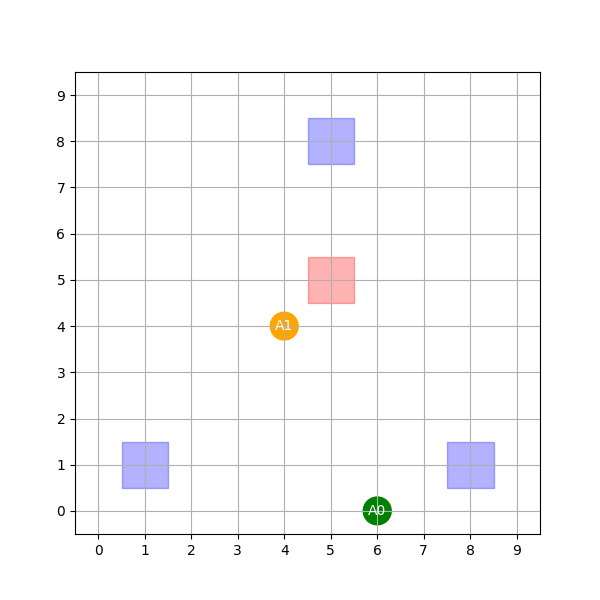

In [28]:
import imageio
import numpy as np
from PIL import Image

def save_agent_behavior_as_gif_colab(env, agents, filename="warehouse_demo.gif", max_steps=100):
    """
    Google Colab環境でエージェントの挙動をシミュレーションし、GIFとして保存する
    """
    frames = []

    # 環境のリセット
    obs = env.reset()
    # 最初の状態をフラット化
    s = flatten_obs(obs)

    print("シミュレーション開始...")

    for t in range(max_steps):
        # 1. 各エージェントのアクションを選択
        actions = {}
        for i in range(env.num_agents):
            # 訓練時と同様のデバイス転送を確認
            state_tensor = s[i].to(device)
            actions[i] = agents[i].get_action(state_tensor)

        # 2. 環境を1ステップ進める
        next_obs, rewards, dones, info = env.step(actions)
        s_prime = flatten_obs(next_obs)

        # 3. フレームを画像データとして取得 (render_frameを使用)
        # render_frame内でplt.close()が呼ばれているためメモリリークを防げます
        frame_image = env.render_frame()
        frames.append(frame_image)

        s = s_prime

        # すべてのエージェントが完了（または全オーダー完了）したら終了
        if any(dones.values()):
            print(f"全オーダー完了！ステップ数: {t}")
            break

    # 4. imageioを使用してGIFを生成
    print(f"GIFを保存中: {filename}...")
    # durationはミリ秒単位 (200ms = 5fps)
    imageio.mimsave(filename, frames, fps=5, loop=0)
    print("保存完了。")

    # Colab上で再生するための表示（オプション）
    from IPython.display import Image as DisplayImage
    return DisplayImage(open(filename, 'rb').read())

# --- 実行方法 ---
# 学習ループ終了後に以下を呼び出します
save_agent_behavior_as_gif_colab(env, agents, "trained_agents.gif")

In [ ]:
# --- 学習パラメータ ---
# 環境パラメータ (以前の定義に合わせてください)
GRID_SIZE = 10
NUM_AGENTS = 2
NUM_ORDERS = 3
PICKUP_LOCATIONS = [(1, 1), (8, 1), (5, 8)]
DROPOFF_LOCATION = (5, 5)

# QMIX学習パラメータ
BATCH_SIZE = 128
GAMMA = 0.99
EPS_START = 1.0
EPS_END = 0.05
EPS_DECAY = 50000        # 減衰をゆっくりにする (ステップ数ベース)
TARGET_UPDATE_INTERVAL = 200 # ターゲットネットワーク更新頻度 (ステップ数)
MEMORY_SIZE = 50000
NUM_EPISODES = 5000      # 実行するエピソード数
MAX_STEPS_PER_EPISODE = 200
LEARNING_FREQ = 4        # 4ステップごとに1回学習

# 環境・エージェントの形状定義
ACTION_SPACE = 5         # 5: 停止, 上, 下, 左, 右
OBS_SHAPE = 2 + 1 + NUM_AGENTS # 位置(2) + 荷物(1) + Agent ID(2) = 5
STATE_SHAPE = (2 + 1) * NUM_AGENTS + NUM_ORDERS # 位置(2) + 荷物(1)) * 2 + 注文(3)

total_steps = 0
episode_rewards = []
losses = []

In [ ]:
def run_qmix_training():
    env = WarehouseEnv(GRID_SIZE, NUM_AGENTS)
    replay_buffer = QMixReplayMemory(MEMORY_SIZE)
    agent = IntegratedQMixAgent(env, OBS_SHAPE, STATE_SHAPE, ACTION_SPACE, gamma=GAMMA)

    total_steps = 0
    rewards_history = []
    losses_history = []

    print(f"--- QMIX Learning Start --- (Agents: {NUM_AGENTS}, Grid: {GRID_SIZE}x{GRID_SIZE})")

    for i_episode in range(1, NUM_EPISODES + 1):
        obs = env.reset()
        episode_reward = 0
        done_flag = False

        for t in range(MAX_STEPS_PER_EPISODE):
            # 1. ε-greedy法による行動選択
            epsilon = EPS_END + (EPS_START - EPS_END) * np.exp(-1. * total_steps / EPS_DECAY)
            actions = agent.get_actions(obs, epsilon)

            # 2. 環境ステップ
            next_obs, rewards, done, info = env.step(actions)

            # チーム全体の終了フラグ
            terminated_flag = all(done.values())

            # 3. リプレイバッファに保存
            # リプレイメモリに保存されるデータは (obs, actions, next_obs, rewards, terminated) のタプル
            agent.memory.push(obs, actions, next_obs, rewards, terminated_flag)

            obs = next_obs
            episode_reward += sum(rewards.values())
            total_steps += 1

            if terminated_flag:
                done_flag = True

            # 4. 学習ステップ
            if len(agent.memory) > BATCH_SIZE * 5 and total_steps % LEARNING_FREQ == 0:
                batch = agent.memory.sample(BATCH_SIZE)
                loss = agent.learn(batch, TARGET_UPDATE_INTERVAL, total_steps)
                losses_history.append(loss)

            if done_flag:
                break

        rewards_history.append(episode_reward)

        # 進捗報告
        if i_episode % 100 == 0:
            avg_reward = np.mean(rewards_history[-100:])
            avg_loss = np.mean(losses_history[-100:]) if losses_history else 0.0
            print(f"Epi: {i_episode}/{NUM_EPISODES} | Steps: {t+1} | Total Steps: {total_steps} | Avg R (100): {avg_reward:.2f} | Avg Loss: {avg_loss:.4f} | Epsilon: {epsilon:.4f}")

    print("\n✅ 学習完了")

    # 5. 結果の可視化
    plt.figure(figsize=(12, 5))
    plt.plot(rewards_history)
    plt.title("QMIX Total Reward per Episode (Moving Avg 100)")
    plt.xlabel("Episode")
    plt.ylabel("Total Reward")
    plt.grid(True)
    plt.show()

run_qmix_training()

--- QMIX Learning Start --- (Agents: 2, Grid: 10x10)


TypeError: 'float' object is not subscriptable

In [ ]:
import torch
import numpy as np
import random
from collections import deque
import matplotlib.pyplot as plt
from typing import Dict, Tuple, List
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import random
import numpy as np
from typing import Dict, Tuple, List
# %debug
# ----------------------------------------------------
# 0. 環境設定と補助クラス (以前の定義を流用)
# ----------------------------------------------------

# 環境パラメータ (以前の定義に合わせてください)
GRID_SIZE = 10
NUM_AGENTS = 2
NUM_ORDERS = 3
PICKUP_LOCATIONS = [(1, 1), (8, 1), (5, 8)]
DROPOFF_LOCATION = (5, 5)

# QMIX学習パラメータ
BATCH_SIZE = 128
GAMMA = 0.99
EPS_START = 1.0
EPS_END = 0.05
EPS_DECAY = 50000        # 減衰をゆっくりにする (ステップ数ベース)
TARGET_UPDATE_INTERVAL = 200 # ターゲットネットワーク更新頻度 (ステップ数)
MEMORY_SIZE = 50000
NUM_EPISODES = 5000      # 実行するエピソード数
MAX_STEPS_PER_EPISODE = 200
LEARNING_FREQ = 4        # 4ステップごとに1回学習

# 環境・エージェントの形状定義
ACTION_SPACE = 5         # 5: 停止, 上, 下, 左, 右
OBS_SHAPE = 2 + 1 + NUM_AGENTS # 位置(2) + 荷物(1) + Agent ID(2) = 5
STATE_SHAPE = (2 + 1) * NUM_AGENTS + NUM_ORDERS # 位置(2) + 荷物(1)) * 2 + 注文(3) = 9

# --- 必須なクラス定義 (以前の回答から流用) ---
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from typing import Dict, Tuple, List
import time
import numpy as np
from IPython import display # Jupyter環境用（オプション）

# 環境設定
GRID_SIZE = 10
NUM_AGENTS = 2
NUM_ORDERS = 3
PICKUP_LOCATIONS = [(1, 1), (8, 1), (5, 8)]
DROPOFF_LOCATION = (5, 5)

class WarehouseEnv:
    def __init__(self, size: int = GRID_SIZE, num_agents: int = NUM_AGENTS):
        self.size = size
        self.num_agents = num_agents
        self.action_space = 5  # 0:待機, 1:上, 2:下, 3:左, 4:右

        # Matplotlib用の図の保持
        self.fig = None
        self.ax = None

        # 状態の初期化
        self.reset()

    def reset(self) -> Dict[int, Tuple]:
        """環境を初期化し、初期状態を返します。"""
        self.agent_positions: Dict[int, Tuple[int, int]] = {
            i: (random.randint(0, self.size - 1), random.randint(0, self.size - 1))
            for i in range(self.num_agents)
        }
        self.agent_holding: Dict[int, bool] = {i: False for i in range(self.num_agents)}
        self.remaining_orders: List[int] = list(range(NUM_ORDERS))
        return self._get_obs()

    def _get_obs(self) -> Dict[int, Tuple]:
        obs = {}
        for i in range(self.num_agents):
            obs[i] = (
                self.agent_positions[i],
                self.agent_holding[i],
                tuple(self.remaining_orders)
            )
        return obs

    def step(self, actions: Dict[int, int]) -> Tuple[Dict, Dict, Dict, Dict]:
        next_positions: Dict[int, Tuple[int, int]] = {}
        rewards: Dict[int, float] = {i: 0.0 for i in range(self.num_agents)}

        # --- 距離ベース報酬のための事前計算 ---
        old_distances = {}
        for i in range(self.num_agents):
            old_distances[i] = self._get_distance_to_target(i)

        # 1. 位置の更新
        for i, action in actions.items():
            current_x, current_y = self.agent_positions[i]
            next_x, next_y = current_x, current_y
            if action == 1: next_y += 1  # 上
            elif action == 2: next_y -= 1  # 下
            elif action == 3: next_x -= 1  # 左
            elif action == 4: next_x += 1  # 右
            next_x = np.clip(next_x, 0, self.size - 1)
            next_y = np.clip(next_y, 0, self.size - 1)
            next_positions[i] = (next_x, next_y)

        # 2. 衝突判定 (変更なし)
        final_positions = self.agent_positions.copy()
        is_collision = False
        for i in range(self.num_agents):
            pos = next_positions[i]
            is_colliding = any(i != j and pos == next_positions[j] for j in range(self.num_agents))
            if is_colliding:
                rewards[i] -= 5.0  # 衝突ペナルティ
                is_collision = True
            else:
                final_positions[i] = pos
        self.agent_positions = final_positions

        # 3. 距離の変化による報酬 (Reward Shaping)
        for i in range(self.num_agents):
            new_dist = self._get_distance_to_target(i)
            # 近づいたら報酬、離れたらペナルティ
            if new_dist < old_distances[i]:
                rewards[i] += 0.1
            elif new_dist > old_distances[i]:
                rewards[i] -= 0.1

            # 時間経過の微小ペナルティ
            rewards[i] -= 0.05

        # 4. ピックアップ・ドロップオフ (イベント報酬)
        for i in range(self.num_agents):
            current_pos = self.agent_positions[i]
            if not self.agent_holding[i]:
                for order_idx in list(self.remaining_orders):
                    if current_pos == PICKUP_LOCATIONS[order_idx]:
                        self.agent_holding[i] = True
                        self.remaining_orders.remove(order_idx)
                        rewards[i] += 10.0  # ピックアップ報酬
                        break
            elif self.agent_holding[i]:
                if current_pos == DROPOFF_LOCATION:
                    self.agent_holding[i] = False
                    rewards[i] += 50.0  # ドロップオフ報酬

        done = {i: len(self.remaining_orders) == 0 and not any(self.agent_holding.values())
                for i in range(self.num_agents)}
        return self._get_obs(), rewards, done, {"collision": is_collision}

    def _get_distance_to_target(self, agent_idx: int) -> float:
        """エージェントから現在のターゲット（荷物または配送先）への最短マンハッタン距離を返します。"""
        curr_pos = self.agent_positions[agent_idx]

        if self.agent_holding[agent_idx]:
            # 荷物を持っているならドロップオフ地点がターゲット
            target = DROPOFF_LOCATION
            return abs(curr_pos[0] - target[0]) + abs(curr_pos[1] - target[1])
        else:
            # 荷物を持っていないなら、残っている荷物の中で最も近いものがターゲット
            if not self.remaining_orders:
                return 0.0

            distances = []
            for order_idx in self.remaining_orders:
                target = PICKUP_LOCATIONS[order_idx]
                dist = abs(curr_pos[0] - target[0]) + abs(curr_pos[1] - target[1])
                distances.append(dist)
            return min(distances)

    def _render_graphic(self, sleep_time):
        if self.fig is None:
            plt.ion() # インタラクティブモードON
            self.fig, self.ax = plt.subplots(figsize=(6, 6))

        self.ax.clear()
        self.ax.set_xlim(-0.5, self.size - 0.5)
        self.ax.set_ylim(-0.5, self.size - 0.5)
        self.ax.set_xticks(range(self.size))
        self.ax.set_yticks(range(self.size))
        self.ax.grid(True)
        self.ax.set_title(f"Orders Remaining: {len(self.remaining_orders)}")

        # ドロップオフ地点 (赤色)
        dx, dy = DROPOFF_LOCATION
        self.ax.add_patch(patches.Rectangle((dx-0.5, dy-0.5), 1, 1, color='red', alpha=0.3, label='Dropoff'))
        self.ax.text(dx, dy, 'Drop', ha='center', va='center', fontsize=8, color='darkred')

        # ピックアップ地点 (青色)
        for idx in self.remaining_orders:
            px, py = PICKUP_LOCATIONS[idx]
            self.ax.add_patch(patches.Rectangle((px-0.5, py-0.5), 1, 1, color='blue', alpha=0.3, label='Pickup'))
            self.ax.text(px, py, 'Pick', ha='center', va='center', fontsize=8, color='darkblue')

        # エージェント (円)
        colors = ['green', 'orange', 'purple', 'cyan']
        for i, pos in self.agent_positions.items():
            ax, ay = pos
            color = colors[i % len(colors)]
            # 荷物を持っている場合は枠線を太く、色を変えるなどの表現
            edgecolor = 'black'
            linewidth = 1
            if self.agent_holding[i]:
                linewidth = 3
                edgecolor = 'red' # 荷物持ち強調

            circle = patches.Circle((ax, ay), 0.3, facecolor=color, edgecolor=edgecolor, linewidth=linewidth, label=f'Agent {i}')
            self.ax.add_patch(circle)
            self.ax.text(ax, ay, f'A{i}', ha='center', va='center', color='white', fontweight='bold')

        plt.draw()
        plt.pause(sleep_time)

# class QMixReplayMemory: ... (以前のリプレイメモリ定義をここに配置)
class QMixReplayMemory:
    def __init__(self, capacity):
        self.memory = deque(maxlen=capacity)
    def push(self, state, action, next_state, reward, done):
        self.memory.append((state, action, next_state, reward, done))
    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)
    def __len__(self):
        return len(self.memory)

# class MLPAgent: ... (MLPAgentの定義をここに配置)
class MLPAgent(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(MLPAgent, self).__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(input_dim, hidden_dim),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden_dim, hidden_dim),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden_dim, hidden_dim),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden_dim, output_dim)
        )
    def forward(self, x):
        return self.net(x)

# class QMixer: ... (QMixerの定義をここに配置)
# 以前の回答から DeepQMixer を QMixer として定義したものを使用
class QMixer(torch.nn.Module):
    def __init__(self, num_agents, state_dim, hidden_dim, hypernet_embed_dim):
        super(QMixer, self).__init__()
        self.num_agents = num_agents
        self.state_dim = state_dim
        self.hidden_dim = hidden_dim

        # ハイパーネットワークの隠れ層サイズ
        hyper_net_hidden = 64 * 2

        # --- ハイパーネットワーク W1 (2層構造化) ---
        self.hyper_w1 = torch.nn.Sequential(
            torch.nn.Linear(state_dim, hyper_net_hidden),
            torch.nn.ReLU(),
            torch.nn.Linear(hyper_net_hidden, hidden_dim * num_agents)
        )
        self.hyper_b1 = torch.nn.Linear(state_dim, hidden_dim)

        # --- ハイパーネットワーク W2 (2層構造化) ---
        self.hyper_w2 = torch.nn.Sequential(
            torch.nn.Linear(state_dim, hyper_net_hidden),
            torch.nn.ReLU(),
            torch.nn.Linear(hyper_net_hidden, hidden_dim)
        )
        self.hyper_b2 = torch.nn.Sequential(
            torch.nn.Linear(state_dim, hyper_net_hidden),
            torch.nn.ReLU(),
            torch.nn.Linear(hyper_net_hidden, 1)
        )

    def forward(self, agent_qs, states):
        batch_size = agent_qs.size(0)

        w1 = torch.abs(self.hyper_w1(states))
        w1 = w1.view(batch_size, self.num_agents, self.hidden_dim)

        agent_qs = agent_qs.view(batch_size, self.num_agents, 1)
        hidden = torch.bmm(agent_qs.transpose(1, 2), w1)

        b1 = self.hyper_b1(states).view(batch_size, 1, self.hidden_dim)
        hidden = F.elu(hidden + b1)

        w2 = torch.abs(self.hyper_w2(states))
        w2 = w2.view(batch_size, self.hidden_dim, 1)

        q_tot = torch.bmm(hidden, w2)

        b2 = self.hyper_b2(states).view(batch_size, 1, 1)

        q_tot = q_tot + b2
        return q_tot.squeeze(-1)

# class IntegratedQMixAgent: ... (前回の修正版クラス定義をここに配置)
class IntegratedQMixAgent:
    def __init__(self, env, obs_shape, state_shape, n_actions, lr=5e-4, gamma=0.99, mixing_embed_dim=32, hidden_dim=64, memory_capacity=50000):
        self.env = env
        self.n_agents = env.num_agents
        self.n_actions = n_actions
        self.gamma = gamma
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.memory = QMixReplayMemory(memory_capacity)
        self.agent_net = MLPAgent(obs_shape, hidden_dim, n_actions).to(self.device)
        self.mixer_net = QMixer(self.n_agents, state_shape, mixing_embed_dim, hypernet_embed_dim=hidden_dim).to(self.device)

        self.target_agent_net = MLPAgent(obs_shape, hidden_dim, n_actions).to(self.device)
        self.target_mixer_net = QMixer(self.n_agents, state_shape, mixing_embed_dim, hypernet_embed_dim=hidden_dim).to(self.device)

        self.target_agent_net.load_state_dict(self.agent_net.state_dict())
        self.target_mixer_net.load_state_dict(self.mixer_net.state_dict())

        params = list(self.agent_net.parameters()) + list(self.mixer_net.parameters())
        self.optimizer = torch.optim.Adam(params, lr=lr)

    def _obs_to_tensor(self, obs: Dict[int, Tuple], is_state: bool = False):
        if is_state:
            state_vec = []
            for i in range(self.n_agents):
                pos_tuple = obs[i][0]
                state_vec.extend([pos_tuple[0] / (GRID_SIZE - 1), pos_tuple[1] / (GRID_SIZE - 1)])
                state_vec.append(1.0 if obs[i][1] else 0.0)

            # 残り注文の処理
            remaining_orders_set = set(obs[0][2])
            for order_idx in range(NUM_ORDERS):
                state_vec.append(1.0 if order_idx in remaining_orders_set else 0.0)
            return torch.FloatTensor(state_vec).to(self.device).unsqueeze(0)

        else:
            tensors = {}
            for i in range(self.n_agents):
                # --- ここも修正：リスト内包表記ではなく明示的なインデックス指定に ---
                pos_tuple = obs[i][0]
                obs_i = [pos_tuple[0] / (GRID_SIZE - 1), pos_tuple[1] / (GRID_SIZE - 1)]

                obs_i.append(1.0 if obs[i][1] else 0.0)
                agent_id_vec = [0.0] * self.n_agents
                agent_id_vec[i] = 1.0
                obs_i.extend(agent_id_vec)
                tensors[i] = torch.FloatTensor(obs_i).to(self.device).unsqueeze(0)
            return tensors

    def get_actions(self, obs: Dict[int, Tuple], epsilon: float) -> Dict[int, int]:
        actions = {}
        if random.random() < epsilon:
            for i in range(self.n_agents):
                actions[i] = random.randint(0, self.n_actions - 1)
        else:
            agent_obs_tensors = self._obs_to_tensor(obs, is_state=False)
            with torch.no_grad():
                for i in range(self.n_agents):
                    q_values = self.agent_net(agent_obs_tensors[i])
                    actions[i] = q_values.max(dim=-1)[1].item()
        return actions

    def learn(self, batch, target_update_interval, update_counter):
        current_state = torch.cat([self._obs_to_tensor(t[0], is_state=True) for t in batch], dim=0)
        next_state = torch.cat([self._obs_to_tensor(t[3], is_state=True) for t in batch], dim=0)
        rewards = torch.FloatTensor([sum(t[2].values()) for t in batch]).to(self.device).unsqueeze(1)
        terminated = torch.FloatTensor([t[4] for t in batch]).to(self.device).unsqueeze(1)
        actions_batch = torch.LongTensor([[t[1][i] for i in range(self.n_agents)] for t in batch]).to(self.device)
        obs_batch = [torch.cat([self._obs_to_tensor(t[0], is_state=False)[i] for t in batch], dim=0) for i in range(self.n_agents)]
        next_obs_batch = [torch.cat([self._obs_to_tensor(t[3], is_state=False)[i] for t in batch], dim=0) for i in range(self.n_agents)]

        # 1. 現在のQ_totの計算
        agent_qs = []
        for i in range(self.n_agents):
            q_vals = self.agent_net(obs_batch[i])
            chosen_q = torch.gather(q_vals, dim=1, index=actions_batch[:, i].unsqueeze(1))
            agent_qs.append(chosen_q)

        agent_qs = torch.cat(agent_qs, dim=1)
        q_tot = self.mixer_net(agent_qs, current_state)

        # 2. TDターゲットの計算 (Double DQN 適用)
        target_agent_qs = []
        with torch.no_grad():
            for i in range(self.n_agents):
                next_q_online = self.agent_net(next_obs_batch[i])
                next_action_argmax = next_q_online.max(dim=1)[1].unsqueeze(1)

                target_q_vals = self.target_agent_net(next_obs_batch[i])

                target_max_q = target_q_vals.gather(dim=1, index=next_action_argmax)
                target_agent_qs.append(target_max_q)

            target_agent_qs = torch.cat(target_agent_qs, dim=1)
            target_q_tot = self.target_mixer_net(target_agent_qs, next_state)

        td_target = rewards + self.gamma * target_q_tot * (1 - terminated)

        # 3. 損失の計算と最適化
        loss = F.mse_loss(q_tot, td_target.detach())

        self.optimizer.zero_grad()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(self.agent_net.parameters(), 10)
        torch.nn.utils.clip_grad_norm_(self.mixer_net.parameters(), 10)

        self.optimizer.step()

        if update_counter % target_update_interval == 0:
            self.update_target_networks()

        return loss.item()

    def update_target_networks(self):
        self.target_agent_net.load_state_dict(self.agent_net.state_dict())
        self.target_mixer_net.load_state_dict(self.mixer_net.state_dict())

    def save_model(self, path="qmix_model.pth"):
        """モデルの重みとオプティマイザの状態を保存"""
        torch.save({
            'agent_net_state_dict': self.agent_net.state_dict(),
            'mixer_net_state_dict': self.mixer_net.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
        }, path)
        print(f"✅ Model saved to {path}")

    def load_model(self, path="qmix_model.pth"):
        """保存された状態を読み込み"""
        if os.path.exists(path):
            print(f"Loading model from {path}")
            checkpoint = torch.load(path, map_location=self.device)
            self.agent_net.load_state_dict(checkpoint['agent_net_state_dict'])
            self.mixer_net.load_state_dict(checkpoint['mixer_net_state_dict'])
            self.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

            # ターゲットネットワークも同期させる
            self.update_target_networks()
            print(f"✅ Model loaded from {path}")
# ----------------------------------------------------
# 3. 学習ループ
# ----------------------------------------------------
def run_qmix_curriculum_training():
    # 初期の環境設定 (Stage 1)
    current_size = 4
    current_orders = 1
    env = WarehouseEnv(size=current_size)
    # ※ WarehouseEnv内で PICKUP_LOCATIONS 等が size に応じて再配置されるよう修正が必要です

    # エージェント初期化 (入力次元は最大サイズに合わせるか、正規化を使用)
    agent = IntegratedQMixAgent(env, OBS_SHAPE, STATE_SHAPE, ACTION_SPACE,
                                gamma=GAMMA, mixing_embed_dim=64, hidden_dim=128)

    total_steps = 0
    rewards_history = []
    losses_history = []
    stage = 1

    print(f"🚀 Curriculum Learning Start | Stage {stage}: {current_size}x{current_size}, Orders: {current_orders}")

    for i_episode in range(1, NUM_EPISODES + 1):
        obs = env.reset()
        # カリキュラムに応じて環境変数を上書き
        env.size = current_size
        # ※実際の環境クラスに合わせて、PICKUP_LOCATIONS[0:current_orders] のみ使う等の処理を env.reset に追加してください

        episode_reward = 0
        done_flag = False

        for t in range(MAX_STEPS_PER_EPISODE):
            epsilon = EPS_END + (EPS_START - EPS_END) * np.exp(-1. * total_steps / EPS_DECAY)
            actions = agent.get_actions(obs, epsilon)

            next_obs, rewards, done, info = env.step(actions)
            terminated_flag = all(done.values())

            # 経験の保存
            agent.memory.push(obs, actions, rewards, next_obs, terminated_flag)

            obs = next_obs
            episode_reward += sum(rewards.values())
            total_steps += 1

            # 学習
            if len(agent.memory) > BATCH_SIZE * 5 and total_steps % LEARNING_FREQ == 0:
                loss = agent.learn(agent.memory.sample(BATCH_SIZE), TARGET_UPDATE_INTERVAL, total_steps)
                losses_history.append(loss)

            if terminated_flag:
                break

        rewards_history.append(episode_reward)

        # --- カリキュラム更新ロジック ---
        if i_episode % 50 == 0:
            avg_reward = np.mean(rewards_history[-50:])
            print(f"Epi: {i_episode} | Avg R: {avg_reward:.2f} | Stage: {stage} | Size: {current_size}")

            # ステージアップ判定
            if stage == 1 and avg_reward > 45:
                stage = 2
                current_size = 7
                current_orders = 2
                print(f"🌟 UP TO STAGE 2: {current_size}x{current_size}")
            elif stage == 2 and avg_reward > 90:
                stage = 3
                current_size = 10
                current_orders = 3
                print(f"🌟 UP TO STAGE 3 (FINAL): {current_size}x{current_size}")

        if i_episode % 100 == 0:
            agent.save_model(path=f"qmix_stage{stage}.pth")

    return agent

# ----------------------------------------------------
# 実行
# ----------------------------------------------------

if __name__ == '__main__':
    agent = run_qmix_curriculum_training()

🚀 Curriculum Learning Start | Stage 1: 4x4, Orders: 1
Epi: 50 | Avg R: -84.19 | Stage: 1 | Size: 4
Epi: 100 | Avg R: -54.63 | Stage: 1 | Size: 4
✅ Model saved to qmix_stage1.pth
Epi: 150 | Avg R: -109.96 | Stage: 1 | Size: 4
Epi: 200 | Avg R: -107.24 | Stage: 1 | Size: 4
✅ Model saved to qmix_stage1.pth
Epi: 250 | Avg R: -86.84 | Stage: 1 | Size: 4
Epi: 300 | Avg R: -67.67 | Stage: 1 | Size: 4
✅ Model saved to qmix_stage1.pth
Epi: 350 | Avg R: -109.87 | Stage: 1 | Size: 4
Epi: 400 | Avg R: -122.84 | Stage: 1 | Size: 4
✅ Model saved to qmix_stage1.pth
Epi: 450 | Avg R: -147.87 | Stage: 1 | Size: 4
Epi: 500 | Avg R: -136.08 | Stage: 1 | Size: 4
✅ Model saved to qmix_stage1.pth
Epi: 550 | Avg R: -128.43 | Stage: 1 | Size: 4
Epi: 600 | Avg R: -90.65 | Stage: 1 | Size: 4
✅ Model saved to qmix_stage1.pth
Epi: 650 | Avg R: -72.10 | Stage: 1 | Size: 4
Epi: 700 | Avg R: -60.70 | Stage: 1 | Size: 4
✅ Model saved to qmix_stage1.pth
Epi: 750 | Avg R: -67.89 | Stage: 1 | Size: 4
Epi: 800 | Avg R: -

In [ ]:
def save_model(agent, path="qmix_model.pth"):
    """モデルの重みとオプティマイザの状態を保存"""
    torch.save({
        'agent_net_state_dict': agent.agent_net.state_dict(),
        'mixer_net_state_dict': agent.mixer_net.state_dict(),
        'optimizer_state_dict': agent.optimizer.state_dict(),
    }, path)
    print(f"✅ Model saved to {path}")

def load_model(agent, path="qmix_model.pth"):
    """保存された状態を読み込み"""
    checkpoint = torch.load(path, map_location=agent.device)
    agent.agent_net.load_state_dict(checkpoint['agent_net_state_dict'])
    agent.mixer_net.load_state_dict(checkpoint['mixer_net_state_dict'])
    agent.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

    # ターゲットネットワークも同期させる
    agent.update_target_networks()
    print(f"✅ Model loaded from {path}")

save_model(agent, path="qmix_model.pth")

✅ Model saved to qmix_model.pth


In [ ]:
from PIL import Image # インポート忘れに注意
import matplotlib.patches as patches  # これが必要です

def save_agent_behavior_gif(agent, env, filename="agent_behavior.gif", max_steps=200):
    frames = []
    obs = env.reset()

    print("🎬 Generating frames for GIF...")

    for t in range(max_steps):
        frame = env.render_frame()

        # --- ここを修正：もし numpy配列なら PIL画像に変換する ---
        if isinstance(frame, np.ndarray):
            # もし [0, 1] の範囲なら 255倍するなどの処理が必要な場合があります
            if frame.max() <= 1.0:
                frame = (frame * 255).astype(np.uint8)
            frame = Image.fromarray(frame)
        # --------------------------------------------------

        frames.append(frame)

        actions = agent.get_actions(obs, epsilon=0.0)
        next_obs, rewards, done, info = env.step(actions)
        obs = next_obs

        if all(done.values()):
            # 最後のフレーム処理
            last_frame = env.render_frame()
            if isinstance(last_frame, np.ndarray):
                last_frame = Image.fromarray((last_frame * 255).astype(np.uint8)) if last_frame.max() <= 1.0 else Image.fromarray(last_frame)
            frames.append(last_frame)
            print(f"✅ Goal reached in {t} steps!")
            break

    if frames:
        # frames[0] が確実に PIL Image になっているので save が使えます
        frames[0].save(
            filename,
            save_all=True,
            append_images=frames[1:],
            duration=200,
            loop=0
        )
        print(f"💾 GIF saved as {filename}")


env = WarehouseEnv(GRID_SIZE, NUM_AGENTS)
save_agent_behavior_gif(agent, env, "warehouse_qmix.gif")

🎬 Generating frames for GIF...
💾 GIF saved as warehouse_qmix.gif
